### Imports & Data Loading

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 13

matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

print(f"Matches: {matches.shape} | Deliveries: {deliveries.shape}")
matches.head()

Matches: (1095, 20) | Deliveries: (179078, 21)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


### Data Cleaning

In [3]:
matches.dropna(subset=['winner', 'toss_winner'], inplace=True)

# Standardize team names (some changed over years)
team_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergaint': 'Rising Pune Supergaints'
}
for col in ['team1', 'team2', 'winner', 'toss_winner']:
    matches[col] = matches[col].replace(team_map)

print(matches.isnull().sum())

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        14
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
dtype: int64


### Toss Analysis(2 plots)

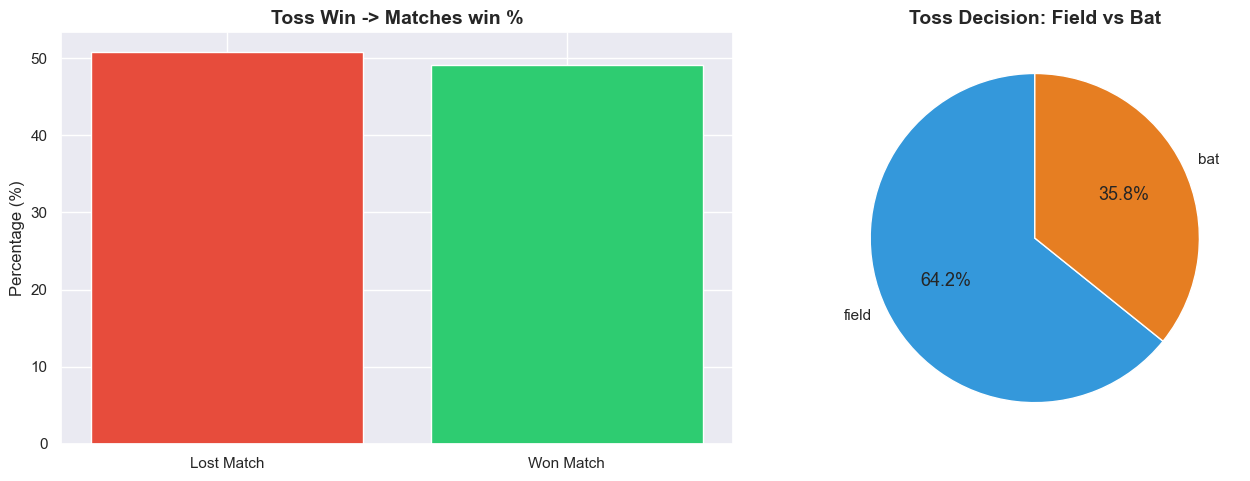

In [7]:
# Did winning toss = winning match ?
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']
toss_win_pct = matches['toss_win_match_win'].value_counts(normalize=True) * 100

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Lost Match', 'Won Match'], toss_win_pct.values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Toss Win -> Matches win %', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')

# Toss decision preference
matches['toss_decision'].value_counts().plot(kind='pie', ax=axes[1],
                                            autopct='%1.1f%%', colors=['#3498db', '#e67e22'], startangle=90)
axes[1].set_title('Toss Decision: Field vs Bat', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../images/toss_analysis.png', dpi=150)
plt.show()

### Season-wise Matche Count (bar chart)

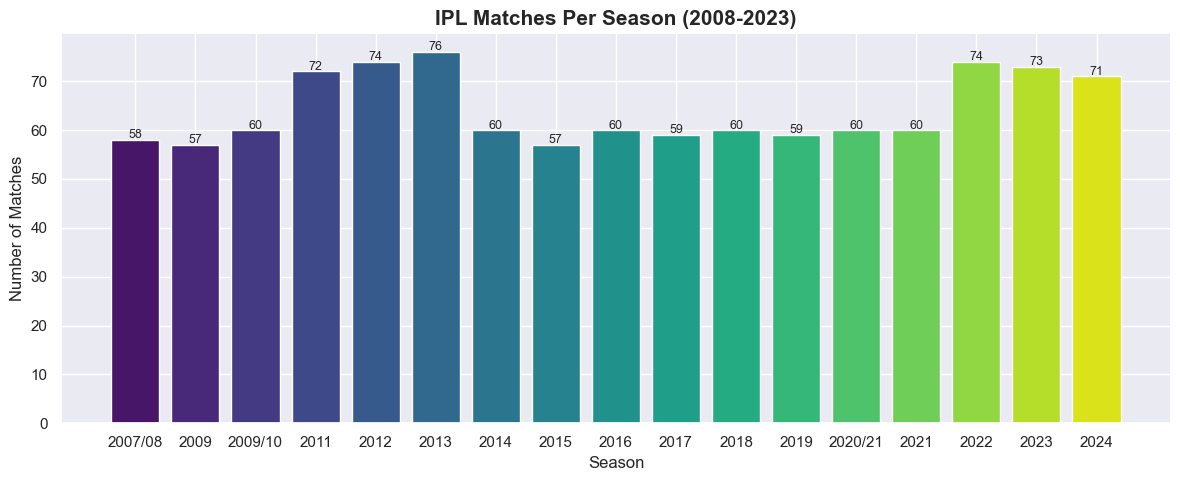

In [9]:
season_counts = matches['season'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
bars = plt.bar(season_counts.index, season_counts.values, color=sns.color_palette("viridis", len(season_counts)))
plt.title('IPL Matches Per Season (2008-2023)', fontsize=15, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../images/season_matches.png', dpi=150)
plt.show()

### Most Successful Teams (horizontal bar)

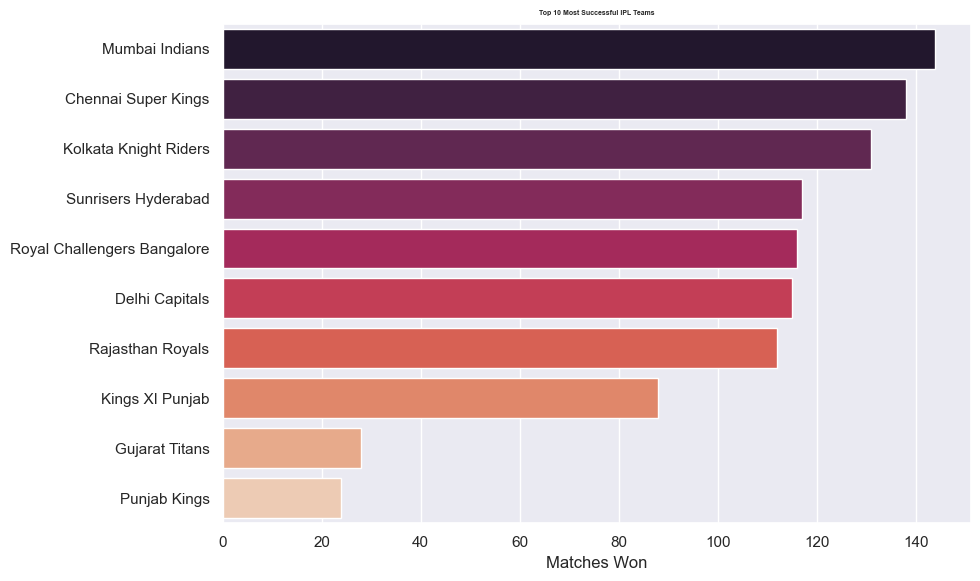

In [11]:
top_winners = matches['winner'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_winners.values, y=top_winners.index, palette='rocket')
plt.title('Top 10 Most Successful IPL Teams', fontsize=5, fontweight='bold')
plt.xlabel('Matches Won')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../images/top_teams.png', dpi=150)
plt.show()

### Top Run Scores 

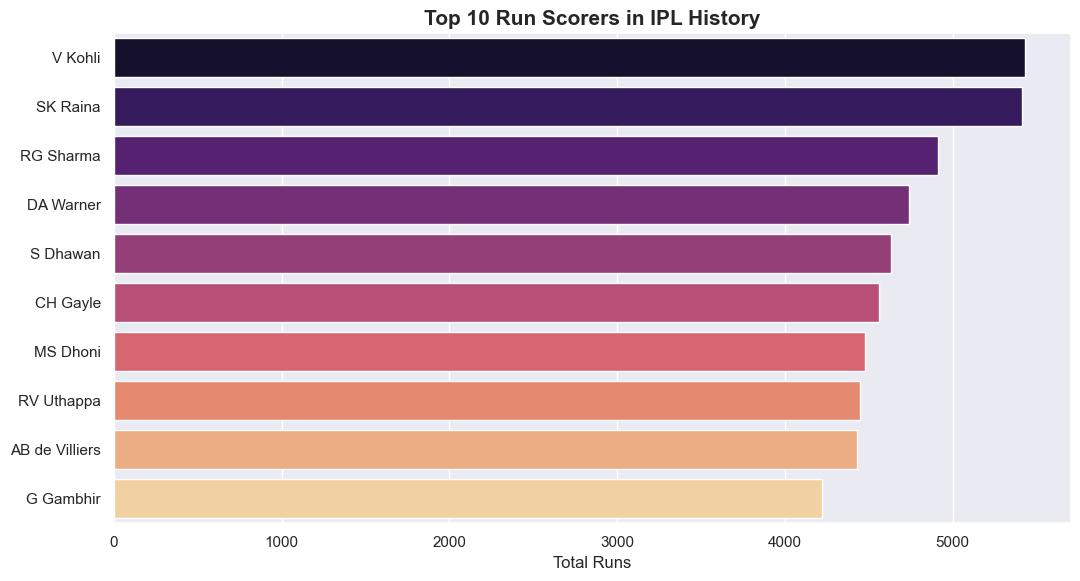

In [15]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(11, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='magma')
plt.title('Top 10 Run Scorers in IPL History', fontsize=15, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../images/top_batsmen.png', dpi=150)
plt.show()